<a href="https://colab.research.google.com/github/dsaoulis/Thesis/blob/main/LGD_with_ESG_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Επεξεργασία δείκτη: ATHEX25...
Επεξεργασία δείκτη: STOXX600...
Επεξεργασία δείκτη: S&P500...
Επεξεργασία δείκτη: EUROSTOXX50...

Η επεξεργασία ολοκληρώθηκε επιτυχώς στη μνήμη!
Το τελικό DataFrame (df_final) έχει 719 γραμμές.



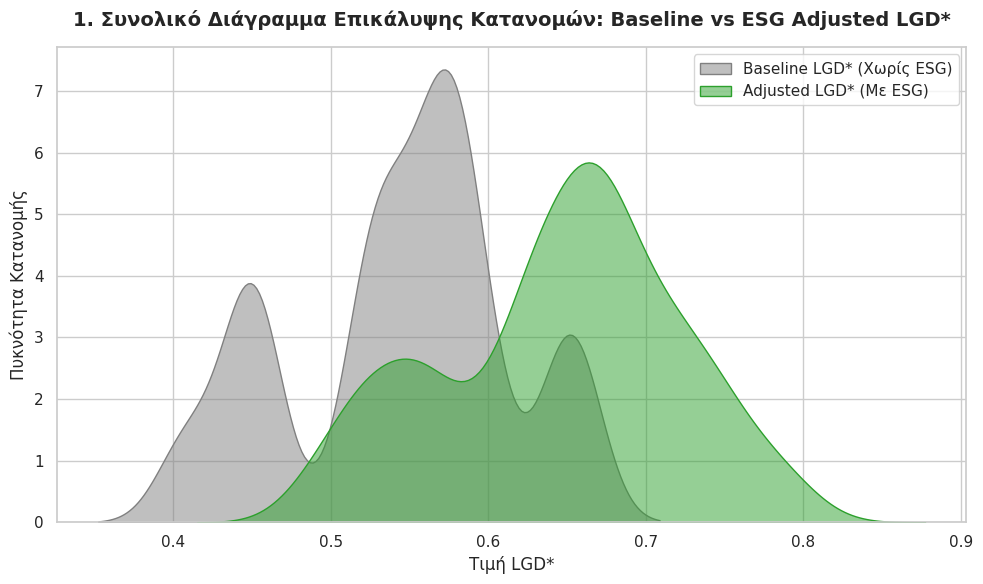

/tmp/ipykernel_3486/3282870359.py:142: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='Delta_LGD', y='LSEG Sector', order=sector_order_boxplot, palette='coolwarm')


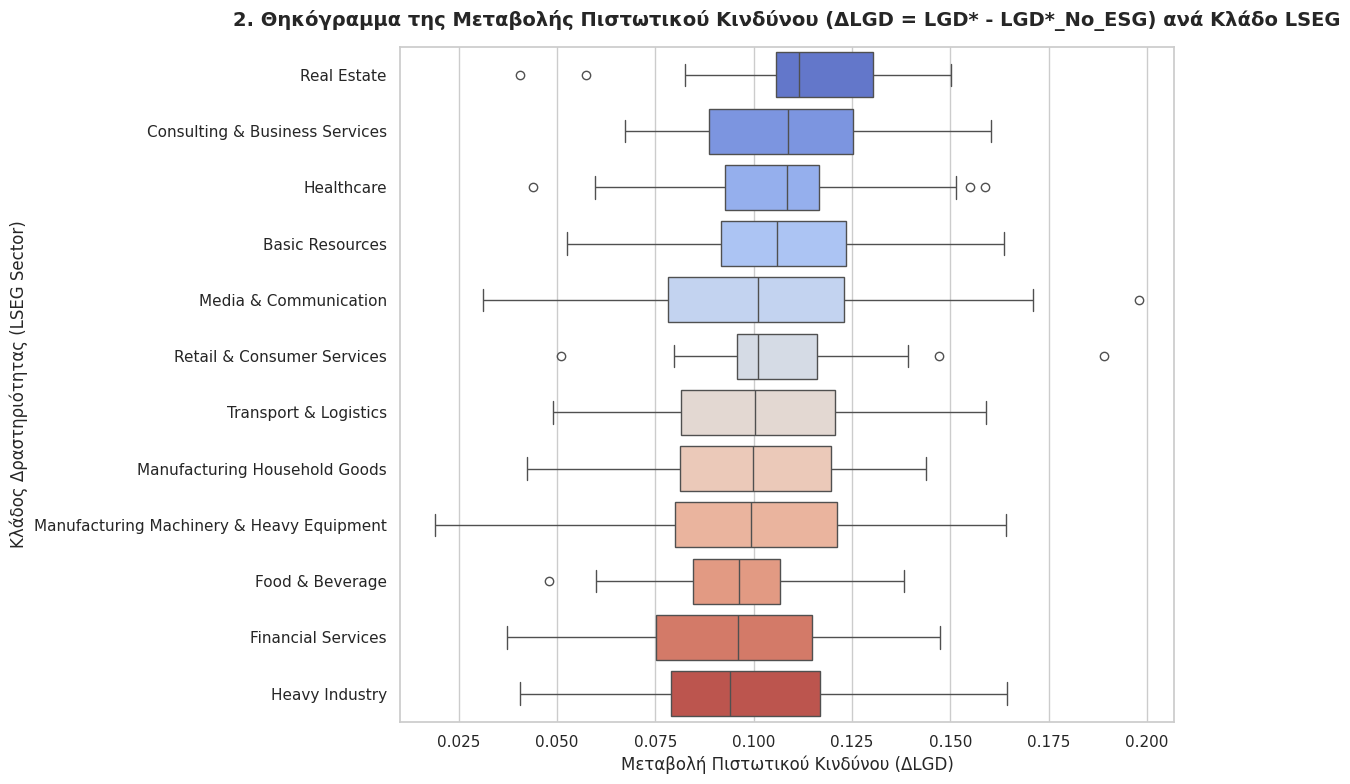

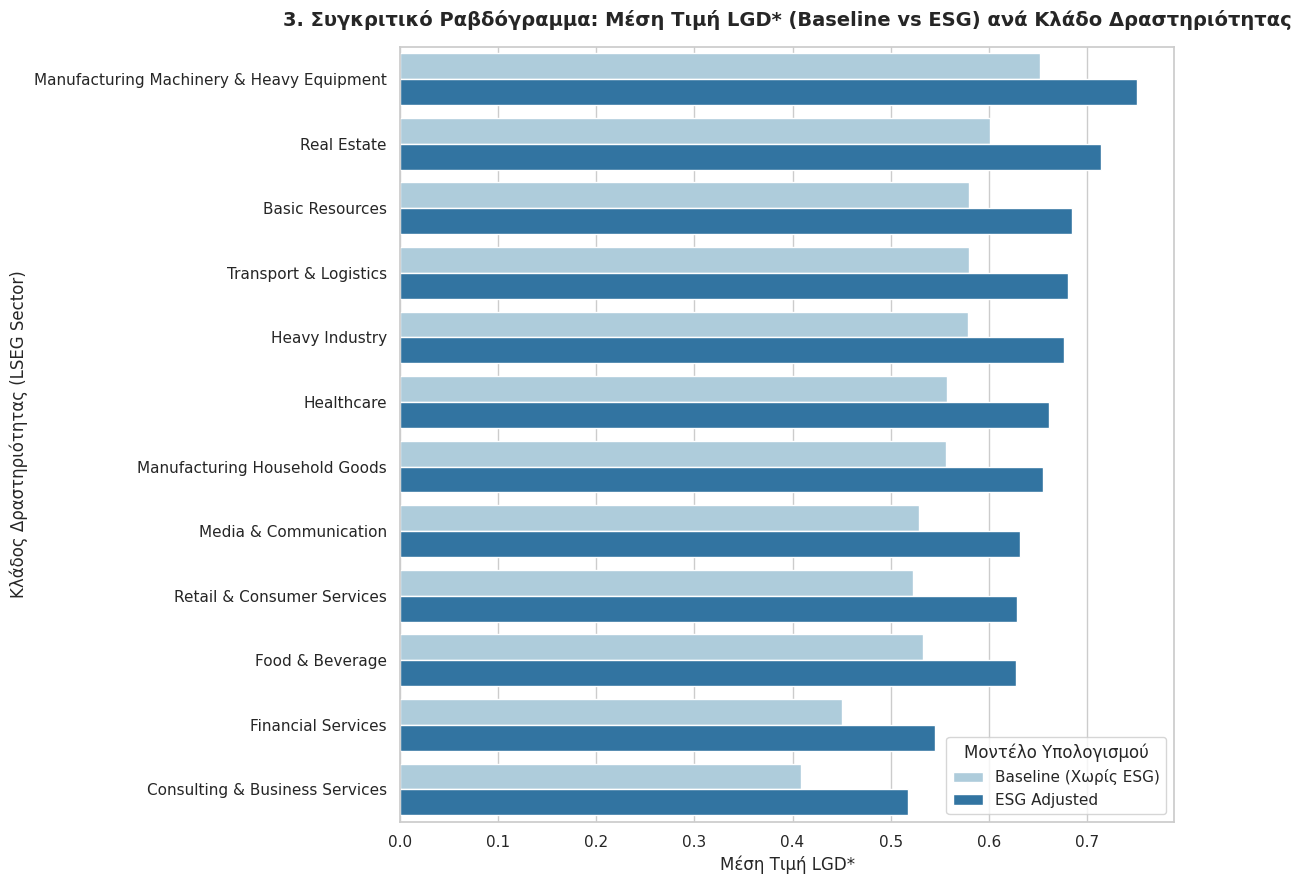

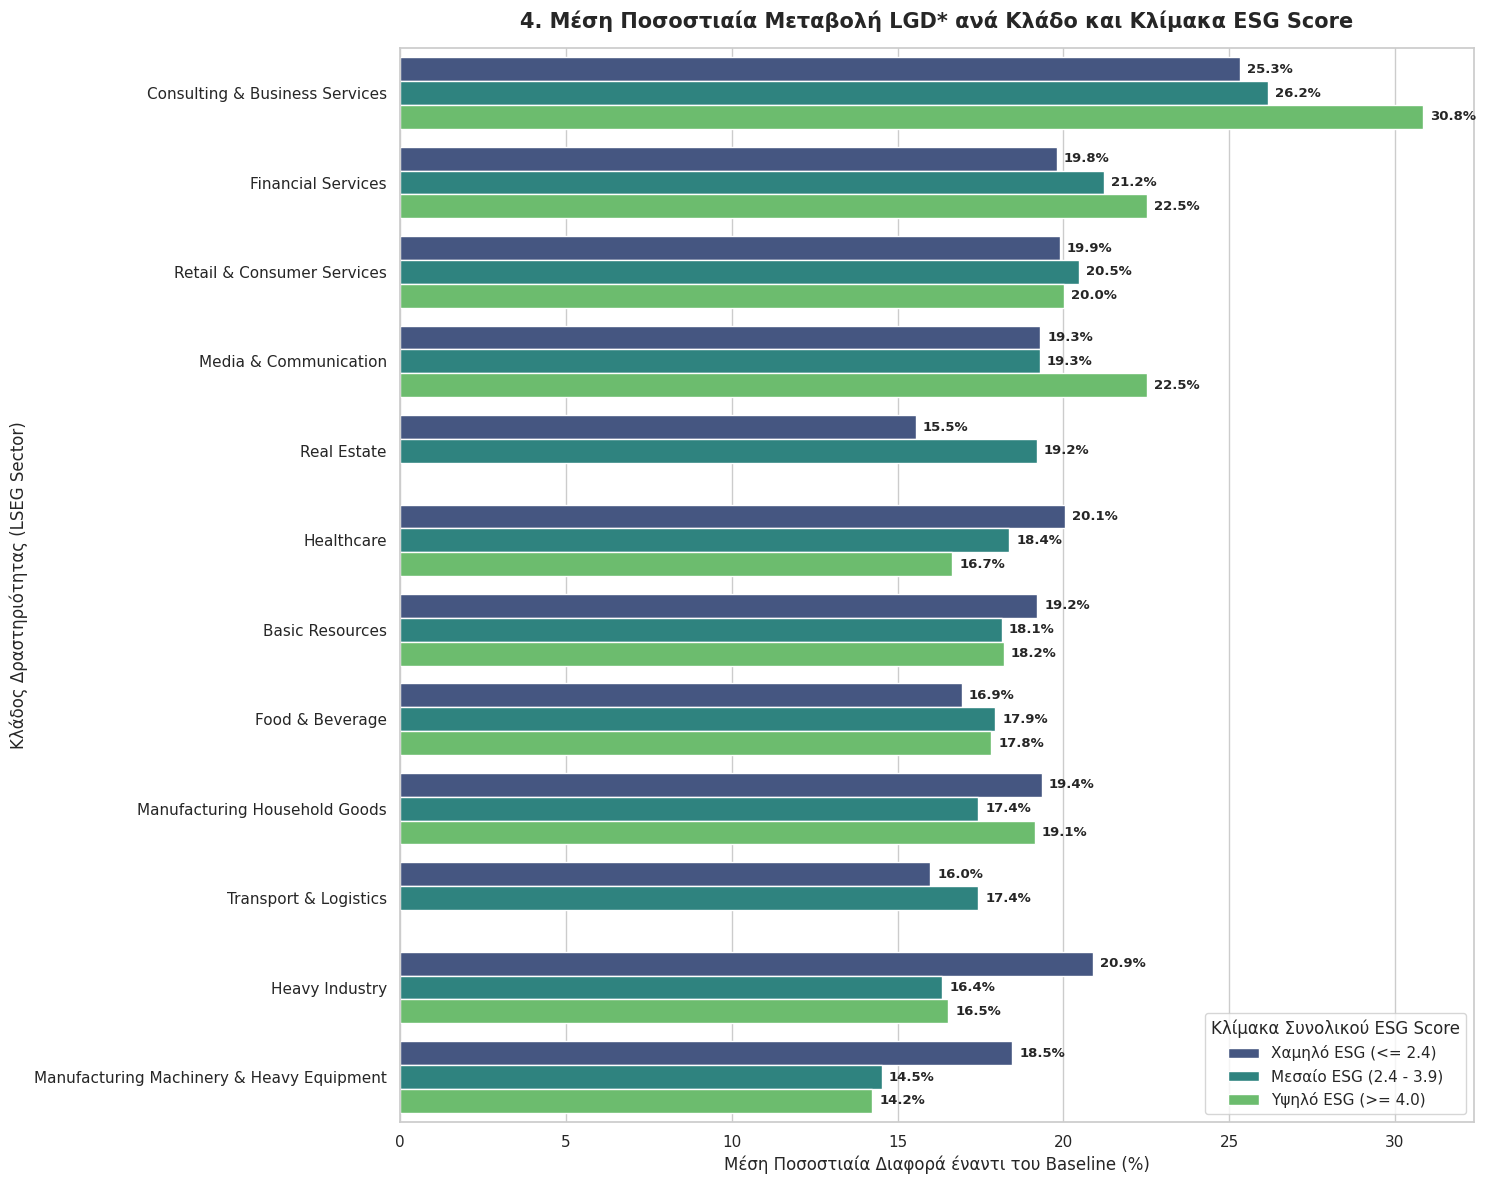

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ρύθμιση του αισθητικού στυλ των γραφικών
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)

# --- 1. ΕSubαγωγή Δεδομένων από το Dropbox ---
dropbox_link = "https://www.dropbox.com/scl/fi/j4ky685dj2qrmn2vygo2q/ALL.xlsx?rlkey=7ag8tb5qvqm148z18i29cqq0z&st=zxsthz2u&dl=0"
download_url = dropbox_link.replace("dl=0", "dl=1")

sheet_names = ['ATHEX25', 'STOXX600', 'S&P500', 'EUROSTOXX50']

# --- 2. Δημιουργία Πίνακα Βαρών (Collaterals) ---
weights_data = {
    'LSEG Sector': [
        'Basic Resources', 'Heavy Industry', 'Manufacturing Machinery & Heavy Equipment',
        'Manufacturing Household Goods', 'Food & Beverage', 'Transport & Logistics',
        'Healthcare', 'Retail & Consumer Services', 'Consulting & Business Services',
        'Media & Communication', 'Financial Services', 'Real Estate'
    ],
    'w_RE': [0.25, 0.20, 0.20, 0.35, 0.40, 0.30, 0.40, 0.50, 0.15, 0.20, 0.10, 0.90],
    'w_Eq': [0.65, 0.70, 0.75, 0.45, 0.30, 0.60, 0.40, 0.15, 0.10, 0.50, 0.05, 0.05],
    'w_St': [0.10, 0.10, 0.10, 0.20, 0.30, 0.10, 0.20, 0.35, 0.75, 0.30, 0.85, 0.05]
}
df_weights = pd.DataFrame(weights_data)

# Λίστα για να συγκεντρώσουμε τα δεδομένα όλων των φύλλων
all_data = []

# --- 3. Επεξεργασία κάθε Φύλλου ---
for sheet in sheet_names:
    print(f"Επεξεργασία δείκτη: {sheet}...")

    df = pd.read_excel(download_url, sheet_name=sheet)

    # Καθαρισμός κενών από τους κλάδους
    df['LSEG Sector'] = df['LSEG Sector'].astype(str).str.strip()

    # Δημιουργία στήλης για να ξέρουμε από ποιον δείκτη προήλθε η εταιρεία
    df['Market_Index'] = sheet

    # Ενώνουμε τα δεδομένα της εταιρείας με τα αντίστοιχα βάρη
    df = pd.merge(df, df_weights, on='LSEG Sector', how='left')

    # --- Υπολογισμός LGD_u ---
    df['LGD_u'] = np.where(df['LSEG Sector'] == 'Financial Services', 0.45, 0.40)

    # --- Υπολογισμός M, h_base, c_base, h_ESG, c_ESG ---
    df['M'] = (((df['w_RE'] + df['w_Eq']) * (5 - df['E_Score'])) +
               (df['w_St'] * ((10 - (df['S_Score'] + df['G_Score'])) / 2))) * 0.2

    df['h_base'] = df['w_RE'] * 0.40 + df['w_Eq'] * 0.45 + df['w_St'] * 0.35
    df['c_base'] = df['w_RE'] * 0.05 + df['w_Eq'] * 0.03 + df['w_St'] * 0.01

    df['h_ESG'] = df['M'] * 0.15
    df['c_ESG'] = df['M'] * 0.02

    # =====================================================================
    # ΣΕΝΑΡΙΟ 1: LGD ΜΕ ESG
    # =====================================================================
    conditions = [
        df['ESG_Score'] <= 2.4,
        (df['ESG_Score'] > 2.4) & (df['ESG_Score'] <= 3.9),
        df['ESG_Score'] >= 4.0
    ]

    ltv_re = np.select(conditions, [0.65, 0.70, 0.75], default=np.nan)
    ltv_eq = np.select(conditions, [0.60, 0.65, 0.70], default=np.nan)
    ltv_st = np.select(conditions, [0.55, 0.60, 0.65], default=np.nan)

    df['LTV'] = (df['w_RE'] * ltv_re) + (df['w_Eq'] * ltv_eq) + (df['w_St'] * ltv_st)

    df['LGD_s'] = 1 - ((1 - df['h_base'] - df['h_ESG'] - df['c_base'] - df['c_ESG']) / df['LTV'])
    df['LGD_s'] = df['LGD_s'].clip(lower=0)
    df['LGD*'] = df['LGD_u'] + df['LGD_s']

    # =====================================================================
    # ΣΕΝΑΡΙΟ 2: BASELINE LGD ΧΩΡΙΣ ESG
    # =====================================================================
    df['LTV_No_ESG'] = (df['w_RE'] * 0.70) + (df['w_Eq'] * 0.65) + (df['w_St'] * 0.60)

    df['LGD_s_No_ESG'] = 1 - ((1 - df['h_base'] - df['c_base']) / df['LTV_No_ESG'])
    df['LGD_s_No_ESG'] = df['LGD_s_No_ESG'].clip(lower=0)

    df['LGD*_No_ESG'] = df['LGD_u'] + df['LGD_s_No_ESG']

    # =====================================================================
    # Υπολογισμός του ESG Delta (Η Διαφορά του Κινδύνου)
    # =====================================================================
    df['Delta_LGD'] = df['LGD*'] - df['LGD*_No_ESG']

    # Καθαρισμός προσωρινών στηλών
    cols_to_drop = ['w_RE', 'w_Eq', 'w_St', 'M', 'LGD_s', 'LGD_s_No_ESG']
    df = df.drop(columns=cols_to_drop)

    # Προσθήκη του dataframe της τρέχουσας λούπας στη γενική λίστα
    all_data.append(df)

# --- 4. Ενοποίηση σε ένα Master DataFrame ---
df_final = pd.concat(all_data, ignore_index=True)

# =====================================================================
# Κατηγοριοποίηση & Υπολογισμός Ποσοστιαίας Μεταβολής
# =====================================================================
conditions_final = [
    df_final['ESG_Score'] <= 2.4,
    (df_final['ESG_Score'] > 2.4) & (df_final['ESG_Score'] <= 3.9),
    df_final['ESG_Score'] >= 4.0
]
esg_categories = ['Χαμηλό ESG (<= 2.4)', 'Μεσαίο ESG (2.4 - 3.9)', 'Υψηλό ESG (>= 4.0)']
df_final['ESG_Scale'] = np.select(conditions_final, esg_categories, default='Unknown')

# Υπολογισμός της ποσοστιαίας διαφοράς (%)
df_final['Pct_Delta_LGD'] = ((df_final['LGD*'] - df_final['LGD*_No_ESG']) / df_final['LGD*_No_ESG']) * 100

print(f"\nΗ επεξεργασία ολοκληρώθηκε επιτυχώς στη μνήμη!")
print(f"Το τελικό DataFrame (df_final) έχει {df_final.shape[0]} γραμμές.\n")


# =====================================================================
# --- 5. Παραγωγή Γραφικών Παραστάσεων ---
# =====================================================================

# --- Γράφημα 1: Συνολικό Διάγραμμα Επικάλυψης Κατανομών (Overlapping KDE Plot) ---
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_final, x='LGD*_No_ESG', fill=True, color='#808080', label='Baseline LGD* (Χωρίς ESG)', alpha=0.5)
sns.kdeplot(data=df_final, x='LGD*', fill=True, color='#2ca02c', label='Adjusted LGD* (Με ESG)', alpha=0.5)
plt.title('1. Συνολικό Διάγραμμα Επικάλυψης Κατανομών: Baseline vs ESG Adjusted LGD*', fontsize=14, pad=15, weight='bold')
plt.xlabel('Τιμή LGD*', fontsize=12)
plt.ylabel('Πυκνότητα Κατανομής', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


# --- Γράφημα 2: Θηκόγραμμα (Boxplot) της Διαφοράς (ΔLGD) ανά Κλάδο ---
plt.figure(figsize=(12, 8))
sector_order_boxplot = df_final.groupby('LSEG Sector')['Delta_LGD'].median().sort_values(ascending=False).index
sns.boxplot(data=df_final, x='Delta_LGD', y='LSEG Sector', order=sector_order_boxplot, palette='coolwarm')
plt.title('2. Θηκόγραμμα της Μεταβολής Πιστωτικού Κινδύνου (ΔLGD = LGD* - LGD*_No_ESG) ανά Κλάδο LSEG', fontsize=14, pad=15, weight='bold')
plt.xlabel('Μεταβολή Πιστωτικού Κινδύνου (ΔLGD)', fontsize=12)
plt.ylabel('Κλάδος Δραστηριότητας (LSEG Sector)', fontsize=12)
plt.tight_layout()
plt.show()


# --- Γράφημα 3: Ομαδοποιημένο Οριζόντιο Ραβδόγραμμα Μέσου LGD ανά Κλάδο ---
df_melted = df_final.melt(id_vars=['LSEG Sector'], value_vars=['LGD*_No_ESG', 'LGD*'],
                          var_name='Μοντέλο', value_name='LGD_Value')
df_melted['Μοντέλο'] = df_melted['Μοντέλο'].map({'LGD*_No_ESG': 'Baseline (Χωρίς ESG)', 'LGD*': 'ESG Adjusted'})

plt.figure(figsize=(12, 9))
sector_order_bars = df_final.groupby('LSEG Sector')['LGD*'].mean().sort_values(ascending=False).index
sns.barplot(
    data=df_melted,
    y='LSEG Sector',
    x='LGD_Value',
    hue='Μοντέλο',
    order=sector_order_bars,
    errorbar=None,
    palette={'Baseline (Χωρίς ESG)': '#a6cee3', 'ESG Adjusted': '#1f78b4'}
)
plt.title('3. Συγκριτικό Ραβδόγραμμα: Μέση Τιμή LGD* (Baseline vs ESG) ανά Κλάδο Δραστηριότητας', fontsize=14, pad=15, weight='bold')
plt.xlabel('Μέση Τιμή LGD*', fontsize=12)
plt.ylabel('Κλάδος Δραστηριότητας (LSEG Sector)', fontsize=12)
plt.legend(title='Μοντέλο Υπολογισμού', fontsize=11, loc='lower right')
plt.tight_layout()
plt.show()


# --- ΑΝΑΒΑΘΜΙΣΜΕΝΟ Γράφημα 4: 36 Μπάρες (Κλάδος x ESG Κλίμακα) ---
# Αυξάνουμε το ύψος (14) για να έχουν οι 36 μπάρες επαρκή χώρο αναπνοής
plt.figure(figsize=(15, 12))

# Ταξινόμηση των κλάδων με βάση τη συνολική μέση ποσοστιαία μεταβολή τους
sector_order_pct = df_final.groupby('LSEG Sector')['Pct_Delta_LGD'].mean().sort_values(ascending=False).index

ax = sns.barplot(
    data=df_final,
    y='LSEG Sector',
    x='Pct_Delta_LGD',
    hue='ESG_Scale',
    hue_order=esg_categories,
    order=sector_order_pct,
    errorbar=None,
    palette='viridis' # Το viridis δίνει μια πολύ επαγγελματική διαβάθμιση (πιο σκούρο σε ανοιχτό)
)

plt.title('4. Μέση Ποσοστιαία Μεταβολή LGD* ανά Κλάδο και Κλίμακα ESG Score', fontsize=15, pad=15, weight='bold')
plt.xlabel('Μέση Ποσοστιαία Διαφορά έναντι του Baseline (%)', fontsize=12)
plt.ylabel('Κλάδος Δραστηριότητας (LSEG Sector)', fontsize=12)
plt.legend(title='Κλίμακα Συνολικού ESG Score', fontsize=11, loc='lower right')

# Αυτόματη τοποθέτηση αριθμητικών labels και στις 36 μπάρες
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=5, weight='bold', fontsize=9.5)

plt.tight_layout()
plt.show()